In [9]:
import pandas as pd
import glob
import os

file_path = '.'
all_files = glob.glob(os.path.join(file_path, "*.csv"))

df_list = []

for filename in all_files:
    try:
        df = pd.read_csv(filename, encoding='ISO-8859-1', low_memory=False)
        
        df = df[['Protocol', 'Retry', 'Signal strength (dBm)', 'Length', 'Noise level (dBm)', 
                 'Channel', 'Day_type', 'Day_of_week', 'Location', 'Day_or_night', 'Source', 'Destination', 'Info']]
        
        df = df[df['Protocol'] == '802.11']
        
        df['Retry'] = df['Retry'].apply(lambda x: 1 if x == 'Frame is being retransmitted' else 0)

        if df['Signal strength (dBm)'].dtype == 'object':
            df['Signal strength (dBm)'] = df['Signal strength (dBm)'].str.replace(' dBm', '').astype(float)
        if df['Noise level (dBm)'].dtype == 'object':
            df['Noise level (dBm)'] = df['Noise level (dBm)'].str.replace(' dBm', '').astype(float)

        df_list.append(df)
        
    except Exception as e:
        print(f"loading {filename} Error: {e}")

combined_data = pd.concat(df_list, ignore_index=True)
combined_data.dropna(inplace=True)

combined_data.to_csv("Clean_Wifi_data.csv", index=False)
print("Done.")



Done.


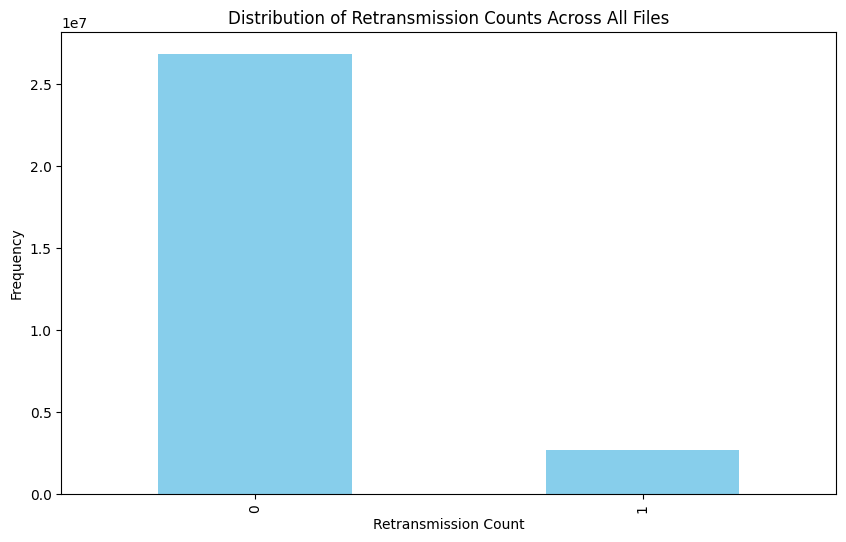

In [13]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

file_path = '.' 
all_files = glob.glob(os.path.join(file_path, "*.csv"))

overall_retry_counts = pd.Series(dtype=int)

for filename in all_files:
    try:
        df = pd.read_csv(filename, encoding='ISO-8859-1', low_memory=False)

        required_columns = ['Retry', 'Source', 'Destination', 'Length', 'Channel', 'Day_type', 'Day_of_week', 'Location', 'Day_or_night']
        if not all(col in df.columns for col in required_columns):
            print(f"{filename} Skip")
            continue
        df = df[df['Protocol'] == '802.11']
        
        df['Retry'] = df['Retry'].apply(lambda x: 1 if x == 'Frame is being retransmitted' else 0)

        retry_counts = df['Retry'].value_counts()
        
        overall_retry_counts = overall_retry_counts.add(retry_counts, fill_value=0)
        
    except Exception as e:
        print(f"Error loading {filename}: {e}")

plt.figure(figsize=(10, 6))
overall_retry_counts.sort_index().plot(kind='bar', color='skyblue')
plt.xlabel('Retransmission Count')
plt.ylabel('Frequency')
plt.title('Distribution of Retransmission Counts Across All Files')
plt.show()

